<a href="https://colab.research.google.com/github/UNICAMP-EA979/2026s1-pi04-filtragem-elginx/blob/main/Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Pedro Henrique Pinheiro Linhares

RA: 175807

Curso: EA979



# Ex04 - Filtragem de Imagens

Nesta atividade vamos entender a operação de convolução e o uso da mesma para filtragem de imagens. Testaremos o uso de **filtros suavizantes**, usados para a remoção de ruído, e **filtros aguçantes**, usados para detecção de bordas.  

- **Filtros suavizantes:** são aqueles que removem a nitidez da imagem fazendo uma média, aritmética ou ponderada, na janela do núcleo. O filtro ponderado suavizante mais comum é o da gaussiana. Filtros suavizantes são muito utilizados para eliminar ruído de uma imagem.

- **Filtros aguçantes:** são aqueles que realçam as bordas da imagem. Alguns dos filtros aguçantes comuns são: Filtro de Sobel, Filtro de Prewitt, Filtro Laplaciano.

Veja mais no notebook sobre [Filtragem no domínio espacial](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/07_Filtragem_no_dominio_espacial.ipynb)

In [ ]:
# Importando as bibliotecas que serão utilizadas
import os
import random
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

Download das imagens:

In [ ]:
zip_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/FiltragemDeImagens.zip"

if not os.path.exists("FiltragemDeImagens.zip"):
    response = requests.get(zip_url)
    with open("FiltragemDeImagens.zip", mode="wb") as file:
        file.write(response.content)

if not os.path.exists("FiltragemDeImagens"):
    shutil.unpack_archive("FiltragemDeImagens.zip")

In [ ]:
path = "FiltragemDeImagens/"

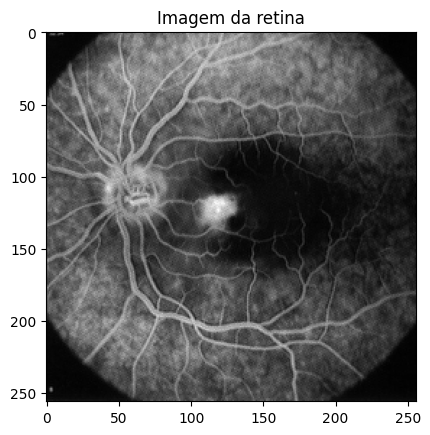

In [ ]:
%matplotlib inline
f = mpimg.imread(path+'retina.tif')
plt.title('Imagem da retina')
plt.imshow(f,cmap='gray')

**ATENÇÃO** - as operações de filtragem alteram os valores e eles podem sair da faixa de 0 a 255. Portanto, fique atento à maneira como você está realizando as operações e visualizando os resultados. Algumas dicas:

- Uma boa prática é realizar as operações em ponto flutuante;
- Quando a visualização não corresponde ao esperado, desconfie que os valores sairam da escala e que os valores, de alguma maneira, estão sendo truncados.

## Parte 1 - Operação de convolução e filtro da média

### Exercício 1.1

Entenda o uso da operação de convolução e experimente usá-la para entender o filtro da média. Siga o seguinte roteiro:
- Crie uma imagem numérica pequena (7x7, por exemplo), crie um filtro de média (kernel 3x3) e use a função **convolve()** da biblioteca **scipy.ndimage** para realizar a filtragem. Verifique numericamente que a filtragem está correta;
- Repita a operação de filtragem na imagem da retina e visualize o resultado;
- Faça experimentos com a imagem da retina variando o tamanho do filtro e compare as imagens resultantes;
- Não se esqueça de comentar os métodos utilizados e resultados obtidos.

In [ ]:
from scipy.ndimage import convolve

img = np.arange(1,50,1)
img = img.reshape(7,7)
kernel = np.ones((3,3)) / (3*3)

img_convol_mean = convolve(img, kernel)

print(img_convol_mean)

[[ 3  4  5  6  7  8  9]
 [ 8  9 10 11 12 13 13]
 [15 15 17 18 19 20 20]
 [22 22 23 24 26 27 27]
 [29 29 30 32 33 34 34]
 [36 37 38 38 40 41 41]
 [41 41 42 43 44 45 46]]


**Resposta:** Criei uma imagem 7x7 que é simplesmente uma contagem de 1 até 49. Após isso, criei um kernel 3x3 onde cada célula possui o valor 1/9. Por fim, eu apliquei a função convolve, a qual aplica a convolução para todos os elementos da imagem, com atenção especial às bordas, pois estas exigem cuidados diferenciados. Por exemplo, caso ele simplesmente não queira se preocupar com as bordas, ele vai diminuir duas linhas e duas colunas da imagem. Para contornar esta situação, a operação convolve realiza padding na imagem. Este padding é do tipo 'reflexão', indicando que ele cria bordas na imagem que correspondem aos valores de: linha seguinte para a borda horizontal superior, linha anterior para a borda horizontal inferior, coluna seguinte para borda vertical esquerda e coluna anterior para borda vertical direita.

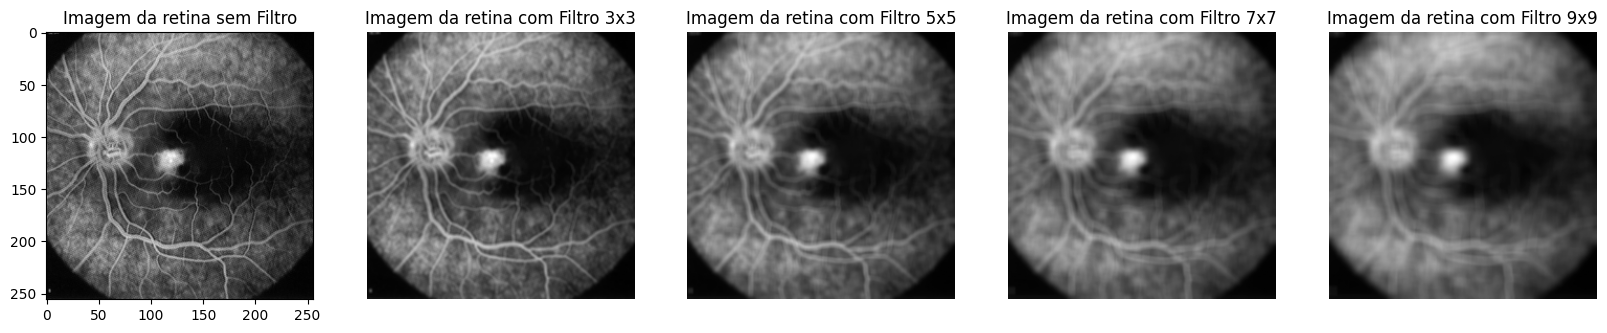

In [ ]:
plt.subplots(1,5, figsize=(20,30))
filtro_tam = [3,5,7,9]

plt.subplot(1,5,1)
plt.title('Imagem da retina sem Filtro')
plt.imshow(f,cmap='gray')
cont = 2
for tam in filtro_tam:
  kernel = np.ones((int(tam), int(tam)), 'float32') / (int(tam)*int(tam))
  f_convol = convolve(f, kernel)
  plt.subplot(1,5,cont)
  plt.title(f'Imagem da retina com Filtro {tam}x{tam}')
  plt.imshow(f_convol,cmap='gray')
  plt.axis('off')
  cont += 1

**Resposta:** A variação do tamanho do filtro gera óbvias mudanças na imagem filtrada. Quanto maior o filtro, mais borrada a imagem fica, ou seja, mais suaves são as transições de pixels nas imagens, o que suaviza as bordas, mas mantém o formato da imagem.

**Resposta:** Para a realização deste exercício eu fiz primeiro

### Exercício 1.2

Repita a operação de filtragem, desta vez variando também o modo de tratamento de borda da função **convolve()** - '*reflect*', '*constant*', '*nearest*', '*mirror*', '*wrap*' - explicando as diferenças encontradas. Dica, você só conseguirá visualizar as diferenças se aumentar o tamanho da máscara (filtro).

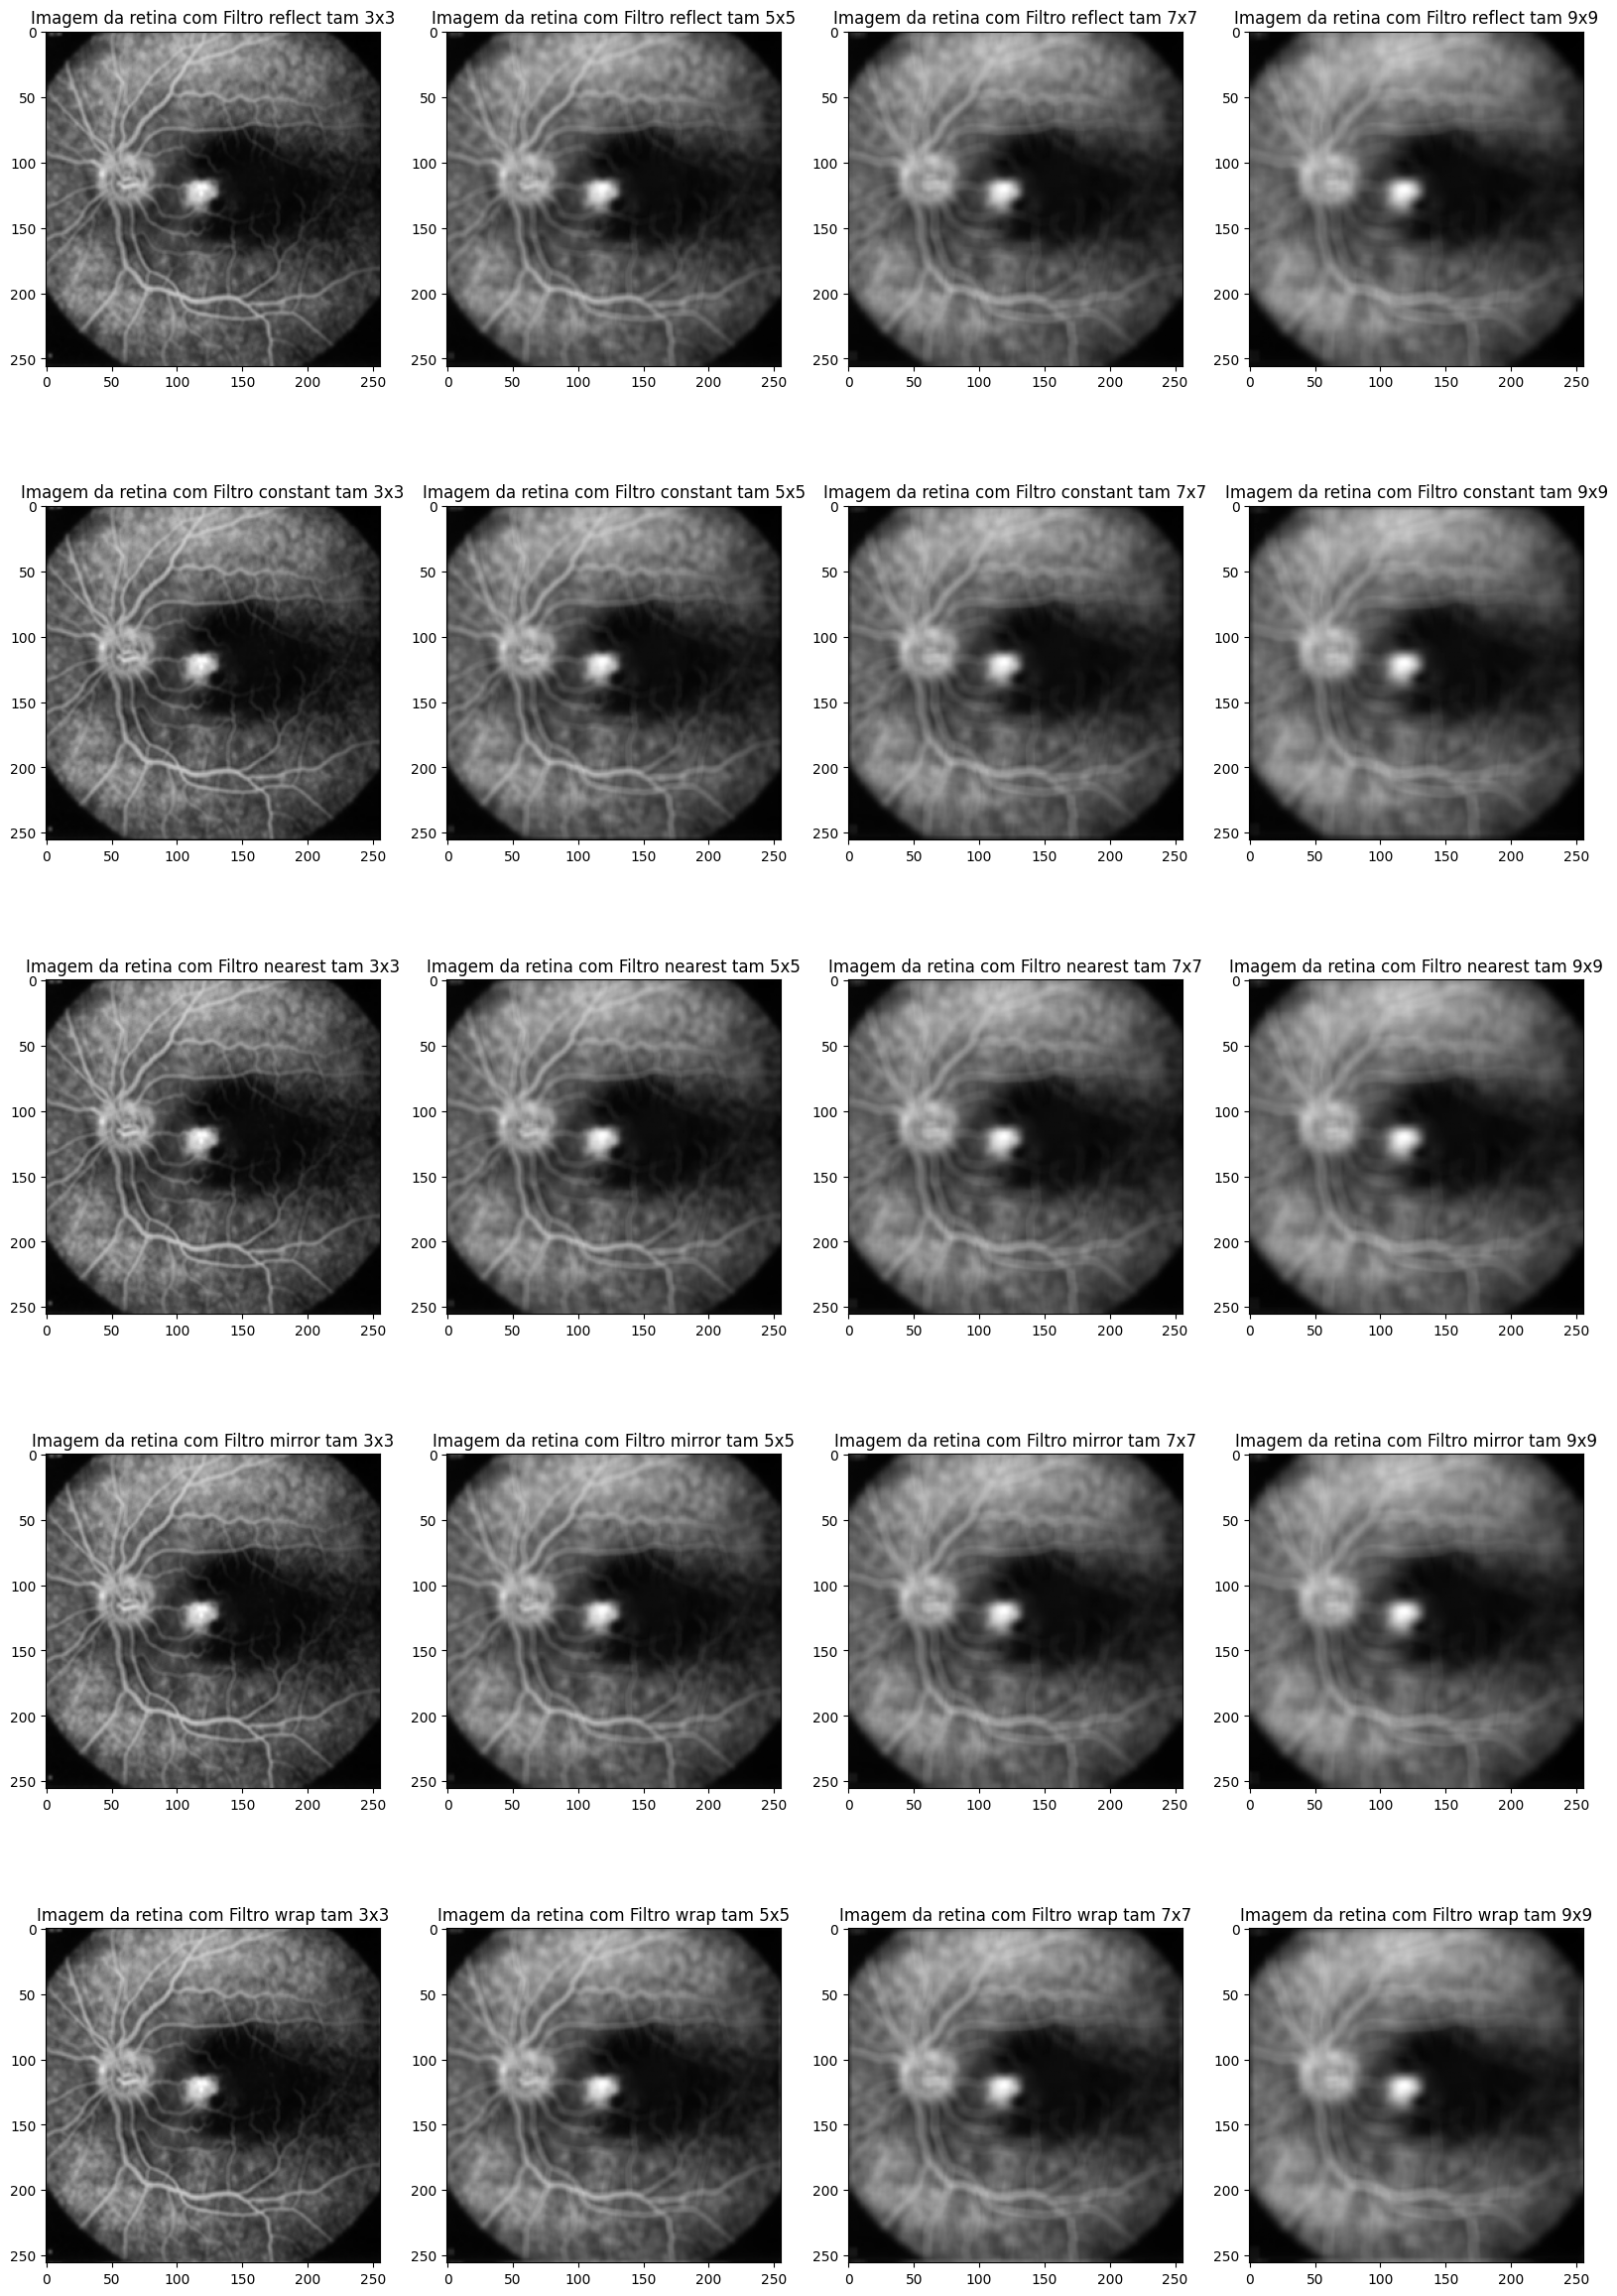

In [ ]:
plt.subplots(5,4, figsize=(20,30))
filtro_tam = [3,5,7,9]
filtro_tipo = ['reflect', 'constant', 'nearest', 'mirror', 'wrap']

cont = 1

for tipo in filtro_tipo:
  for tam in filtro_tam:
    kernel = np.ones((int(tam), int(tam))) / (int(tam)*int(tam))
    f_convol = convolve(f, kernel, mode=tipo)
    plt.subplot(5,4,cont)
    plt.title(f'Imagem da retina com Filtro {tipo} tam {tam}x{tam}')
    plt.imshow(f_convol,cmap='gray')
    cont += 1

**Resposta:** A mudança de modo da convolução gera uma alteração no tratamento das bordas.

Tipos:
  - Reflect - Para a borda superior, reflete a segunda linha, para a inferior, reflete a penúltima, para a esquerda, reflete a segunda coluna e para a direita, reflete a penúltima coluna.
  - Constant - Adiciona uma borda de valor constante, onde o default é 0, mas pode ser modificado.
  - Nearest - Extende o pixel da borda para o padding.
  - Mirror - Cria os pixels do padding a partir do reflexo do pixel da borda, ou seja, para um pixel na borda direita, ele reflete os pixels da esquerda.
  - Wrap - O padding adicionado na imagem é resultante da repetição do valor da borda contrária. Por exemplo, padding superior é a última linha inferior.

## Parte 2 - Filtro gaussiano e redução de ruído

### Exercício 2.1

Teste a propriedade de decomposição das máscaras da convolução, ou seja, crie um filtro gaussiano bi-dimensional (3,3) a partir de 2 filtros unidimensionais (3,1) e (1,3). Crie também o filtro bi-dimensional diretamente e cheque se os resultados são equivalentes. Comente os métodos utilizados.

[[1 1 0 ... 1 0 0]
 [0 0 1 ... 1 0 0]
 [0 1 0 ... 0 1 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 1 0]
 [1 1 0 ... 1 0 1]]


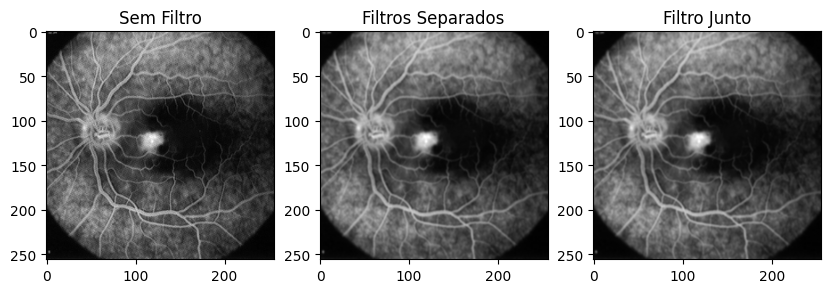

In [ ]:
g_x = np.array([[0.25, 0.5, 0.25]])
g_y = np.array([[0.25],[0.5],[0.25]])

g = g_x * g_y # Filtro gaussiano 3x3

f_convol_x = convolve(f, g_y)
f_convol_y = convolve(f_convol_x, g_x)

f_convol_dir = convolve(f, g)

print(f_convol_dir - f_convol_y)

plt.subplots(1,3, figsize=(10,18))
plt.subplot(1,3,1)
plt.title('Sem Filtro')
plt.imshow(f, cmap='gray')
plt.subplot(1,3,2)
plt.title('Filtros Separados')
plt.imshow(f_convol_y, cmap='gray')
plt.subplot(1,3,3)
plt.title('Filtro Junto')
plt.imshow(f_convol_dir, cmap='gray');

**Resposta:** Para realizar a criação do kernel, primeiro eu criei diretamente uma matriz 1x3 com os valores do kernel gaussiano, depois eu criei uma matriz 3x1 com os valores na mesma ordem. Tendo isso em mãos, eu pude criar o kernel completo 3x3 a partir de um produto de matrizes, resultando no kernel completo.

Para tratamento separado, eu apliquei o filtro a partir da convolução entre a imagem e o filtro 3x1, depois eu realizei a convolução entre a imagem resultante e o filtro 1x3.

Após isso eu realizei a convolução direta entre a imagem original e o filtro 3x3.

Por fim, eu subtraí as imagens para ver a diferença entre os valores de pixels. A partir disso, eu pude vislumbrar a real diferença entre as duas operações. Com a aplicação do tratamento com filtros separados são gerados mais erros de aproximação, devido à quantidade de divisões que são realizadas. Com a aplicação da operação direta entre a imagem e o kernel 3x3, acontecem menos erros de aproximação. Porém, no final as diferenças são ínfimas. Permitindo concluir que as operações são equivalentes.

### Exercício 2.2

Teste a aplicação de filtros suavizantes para redução de ruído: Adicione ruído gaussiano à imagem da retina (sugestão: use **np.random**) e depois tente remover o ruído com o filtro da média e com o filtro gaussiano. Você pode aumentar os filtros se quiser. Comente os métodos utilizados e resultados obtidos.

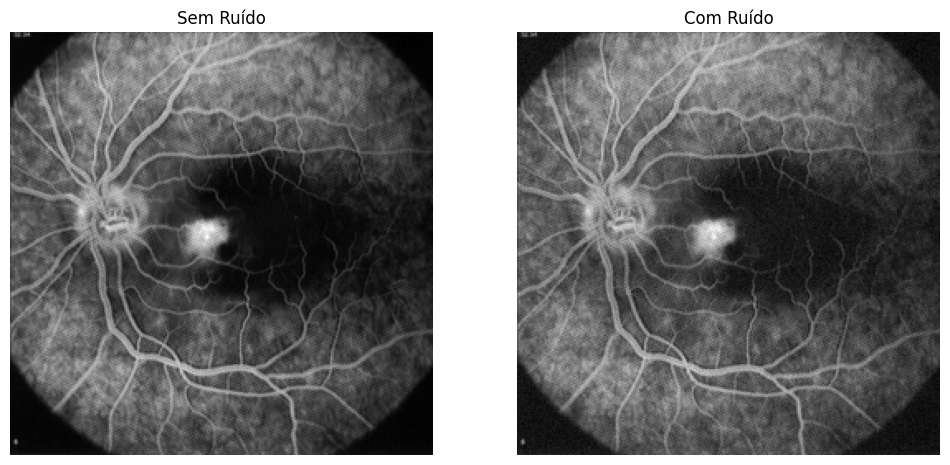

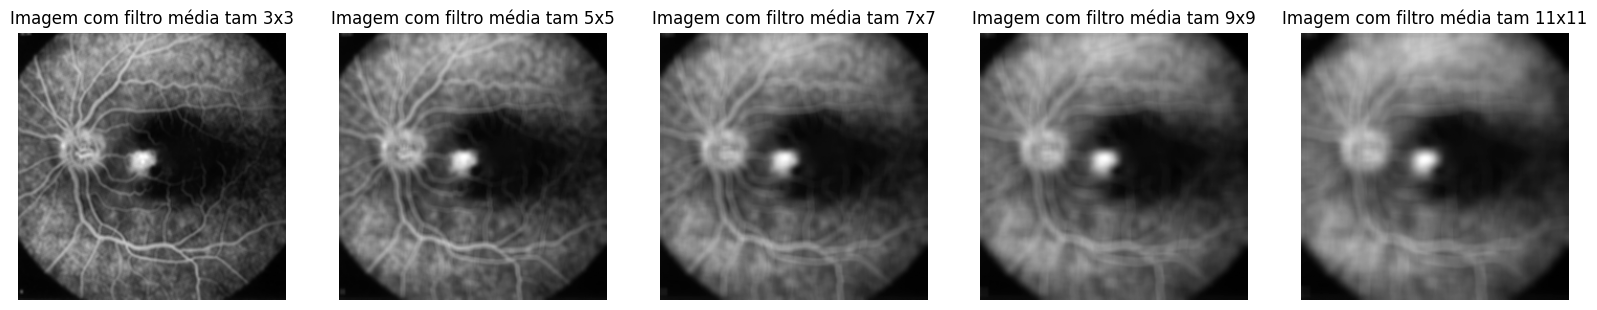

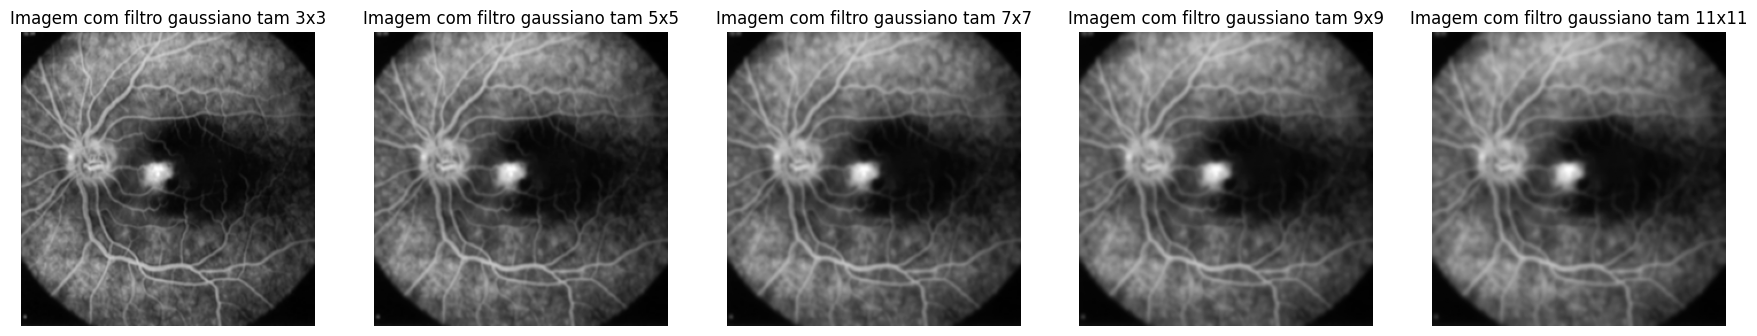

In [ ]:
from scipy.special import factorial

# Aplicação de ruído gaussiano na imagem da retina
ruido_gauss = np.random.normal(loc=30, scale=5, size=(f.shape[0]*f.shape[1]))
ruido_gauss = ruido_gauss.reshape((256,256))

f_gausseado = f + ruido_gauss

plt.subplots(1,2, figsize=(12,24))

plt.subplot(1,2,1)
plt.title('Sem Ruído')
plt.imshow(f, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Com Ruído')
plt.imshow(f_gausseado, cmap='gray')
plt.axis('off')

# Tratamento com filtro da média
plt.subplots(1,5, figsize=(20,24))
cont = 1
for i in range(3, 12, 2):
  filtro_media = np.ones((i,i)) / (i*i)
  f_media = convolve(f, filtro_media)
  plt.subplot(1,5,cont)
  plt.title(f'Imagem com filtro média tam {i}x{i}')
  plt.imshow(f_media, cmap='gray')
  plt.axis('off')
  cont += 1

# Tratamento com filtro gaussiano
plt.subplots(1,5, figsize=(22,30))
cont = 1
for i in range(3, 12, 2):
  k = np.arange(0,i)
  k = k.reshape(1,len(k))
  n = np.ones((1,i)) * (i-1)
  filtro_gauss_lin = (factorial(n)/(factorial(k) * factorial(n-k))) / (2**(i-1))
  g = filtro_gauss_lin.T * filtro_gauss_lin
  f_gauss = convolve(f, filtro_gauss_lin.T)
  f_gauss = convolve(f_gauss, filtro_gauss_lin)
  plt.subplot(1,5,cont)
  plt.title(f'Imagem com filtro gaussiano tam {i}x{i}')
  plt.imshow(f_gauss, cmap='gray')
  plt.axis('off')
  cont += 1

**Resposta:** Este exercício está dividido em duas partes.
  - Parte 1: A aplicação do ruído gaussiano ocorre com a adição de valores aleatórios aos pixels da imagem, que formem uma distribuição normal. Para isso, eu crio uma matriz com o tamanho da imagem em questão e somo os valores delas duas. Desta forma, crio a imagem com ruído gaussiano.
  - Parte 2: Aplicar um filtro que seja capaz de remover o ruído da imagem. Para isso, eu usei o filtro da média e o filtro gaussiano. Para o filtro da média eu criei 5 kernels de tamanhos diferentes(3,5,7,9,11) e apliquei sobre a imagem. Após isso, eu apliquei diferentes tamanhos(3,5,7,9,11) de filtros gaussianos à imagem.
Por fim, foi possível concluir, a partir da comparação das imagens filtradas, que o filtro da média de tamanho 3x3 foi o mais efetivo na sua categoria. Já o filtro gaussiano teve um bom tratamento nos primeiros tamanhos de kernel, mas, a partir do 9x9 começou a perder muitos detalhes. Porém, de qualquer forma, o filtro ideal foi o gaussiano de tamanho 3x3. Pois apresentou melhor tratamento do ruído, mantendo ainda os detalhes da imagem original antes do ruído.

## Parte 3 - Filtro de Sobel e detecção de bordas

Existem vários filtros que procuram realçar as bordas da imagem. Um dos mais conhecidos é o Operador Sobel, composto por uma máscara vertical (Sv) e uma máscara horizontal (Sh).

In [ ]:
Sv = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n',Sv)

Sh = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n',Sh)

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Para detectar bordas de uma imagem usando o Filtro de Sobel, precisamos fazer a filtragem da imagem usando tanto a máscara vertical, quanto a horizontal. No final, acabaremos com 2 imagens resultantes, uma reforçando as bordas verticais e outra reforçando as bordas horizontais, como exemplificado abaixo.

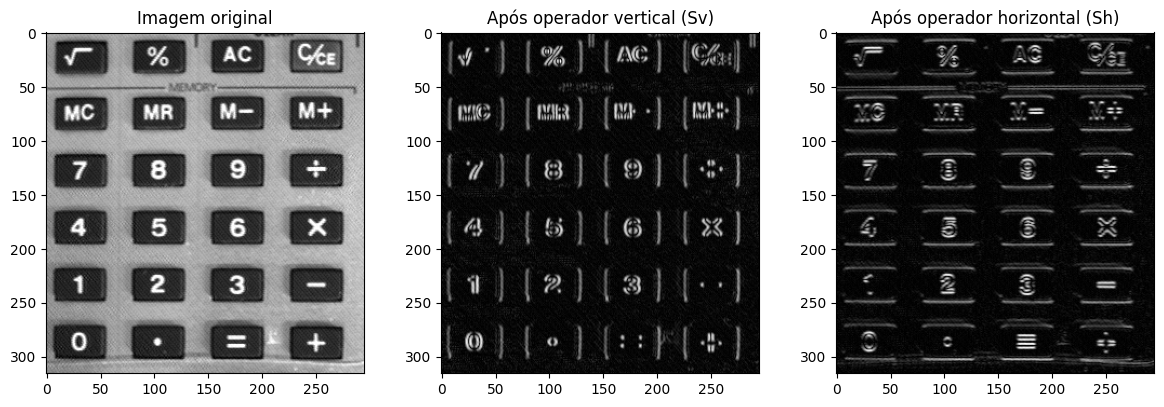

In [ ]:
img = mpimg.imread(path+'keyb.tif')
img_sv = mpimg.imread(path+'keyb_sv.tif')
img_sh = mpimg.imread(path+'keyb_sh.tif')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.1 - Visualizando as bordas verticais e horizontais em 2 imagens separadas

Experimente filtrar as imagens abaixo com os Filtros de Sobel vertical e horizontal e visualize o resultado. Para cada imagem, você deve obter uma imagem fitrada pelo Filtro de Sobel vertical - **fv** - e uma imagem filtrada pelo Filtro de Sobel horizontal - **fh**. Comente sobre os resultados obtidos. As imagens geradas estão de acordo com o exemplo apresentado para a imagem da calculadora? Em caso negativo, explique o porquê e tente fazer com que as imagens fiquem mais semelhantes.

In [ ]:
img1 = mpimg.imread(path+'retina.tif')


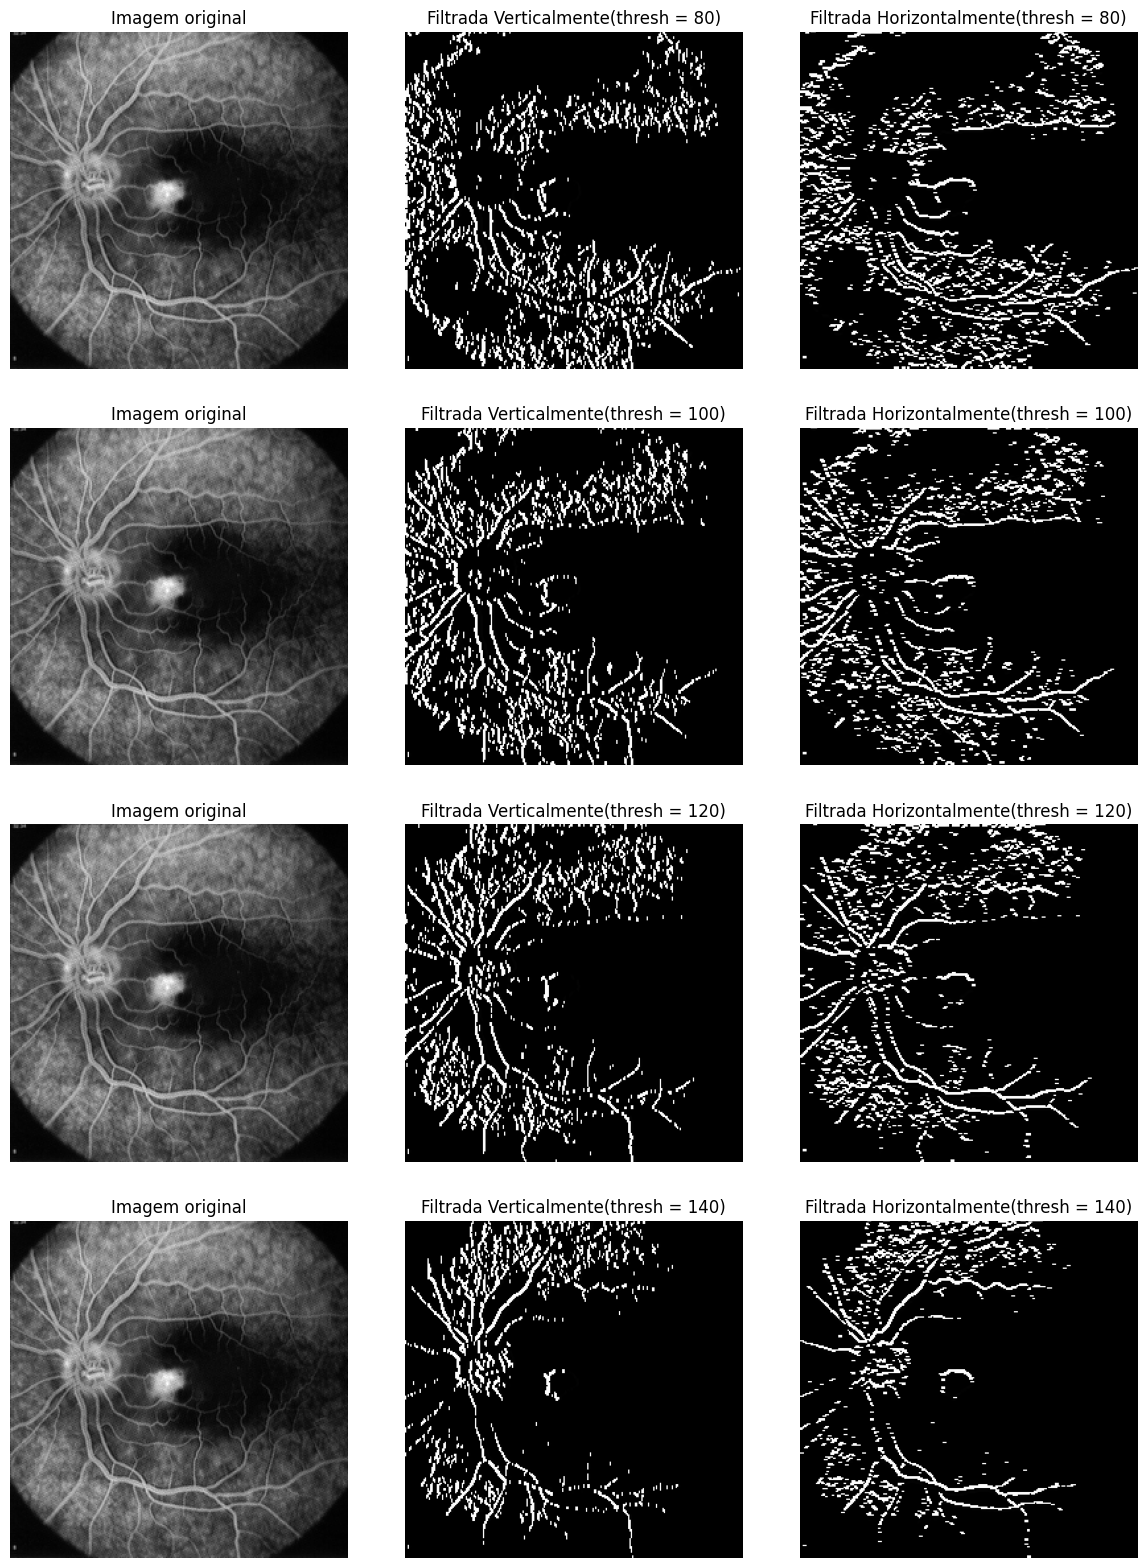

In [ ]:
fig, axs = plt.subplots(4,3, figsize=(12,16))
plt.tight_layout()
filtradas = []

T1 = np.arange(256).astype('uint8') # função identidade
cont = 1
for thresh in range(80, 141, 20):
  tmp = (T1 > thresh).astype(float) # threshold 128
  T4 = ((tmp-tmp.min())*255/(tmp.max()-tmp.min())).astype('uint8') # normalização de 0 a 255
  img1_f = T4[img1]

  img1_v = convolve(img1_f, Sv)
  img1_h = convolve(img1_f, Sh)
  filtradas.append(img1_v)
  filtradas.append(img1_h)

  plt.subplot(4, 3, cont)
  plt.imshow(img1, cmap='gray')
  plt.title('Imagem original')
  plt.axis('off')
  cont += 1

  plt.subplot(4, 3, cont)
  plt.imshow(img1_v, cmap='gray')
  plt.title(f'Filtrada Verticalmente(thresh = {thresh})')
  plt.axis('off')
  cont += 1

  plt.subplot(4, 3, cont)
  plt.imshow(img1_h, cmap='gray')
  plt.title(f'Filtrada Horizontalmente(thresh = {thresh})')
  plt.axis('off')
  cont += 1

---

In [ ]:
img2 = mpimg.imread(path+'cameraman.tif')

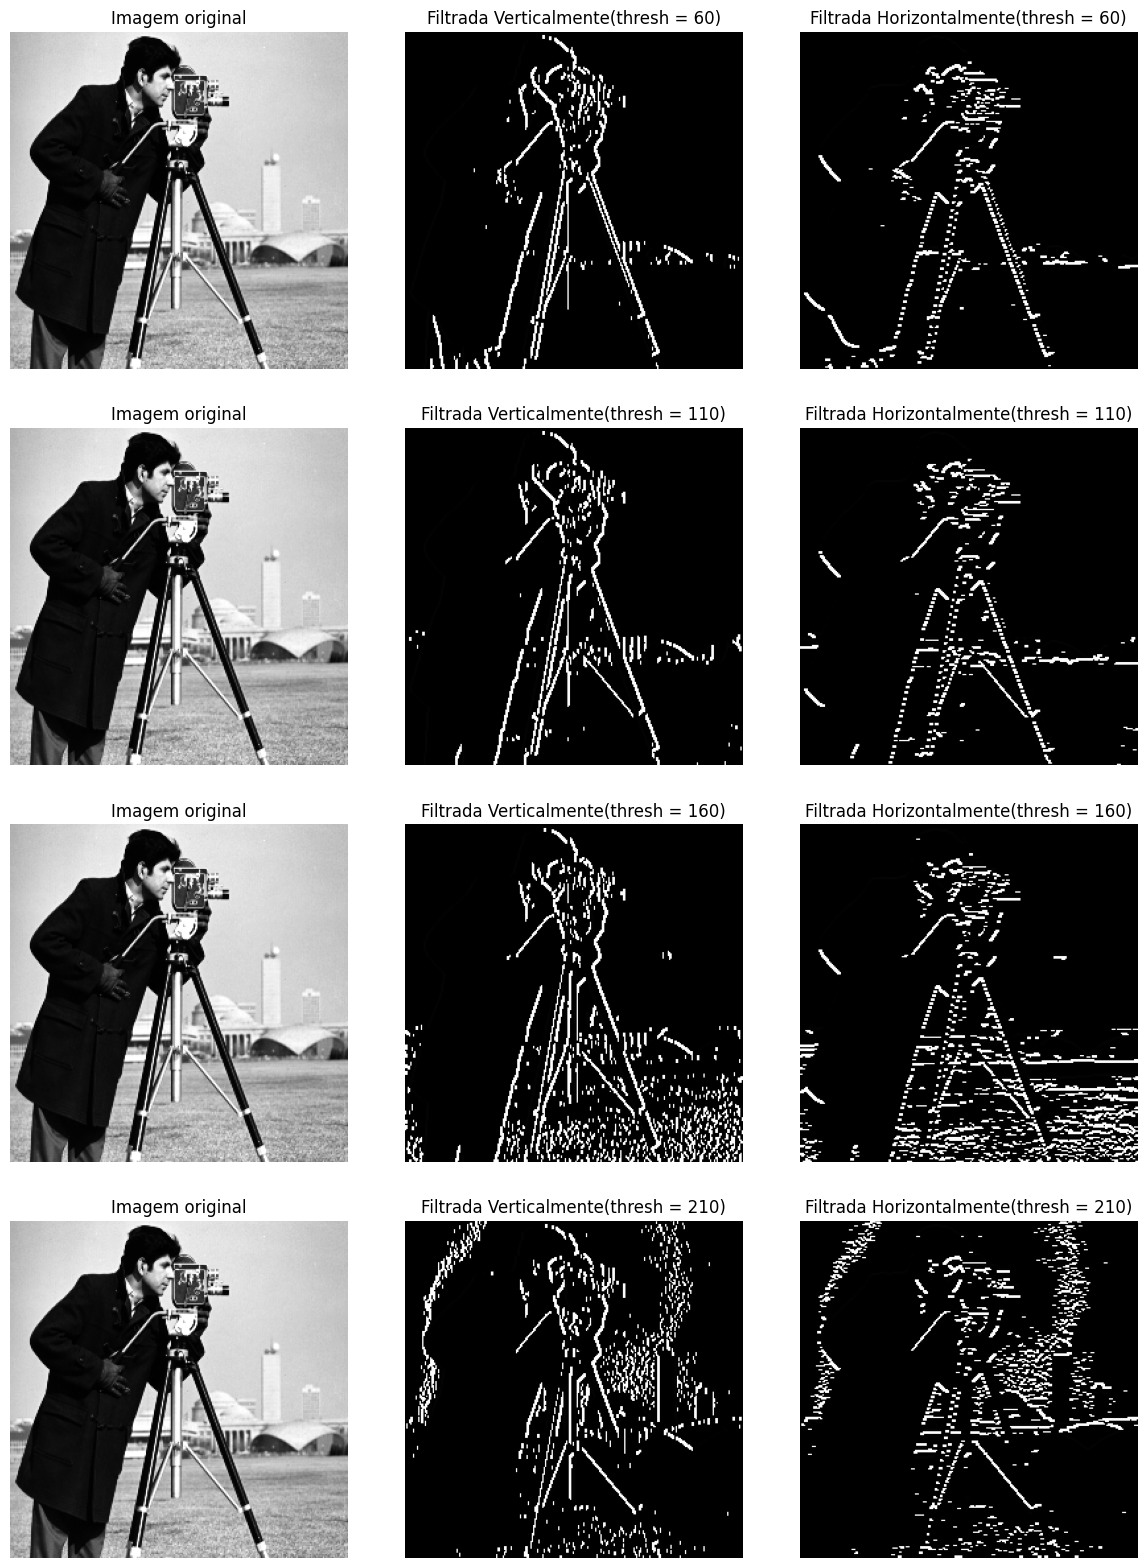

In [ ]:
fig, axs = plt.subplots(4,3, figsize=(12,16))
plt.tight_layout()

T1 = np.arange(256).astype('uint8') # função identidade
cont = 1
for thresh in range(60, 211, 50):
  tmp = (T1 > thresh).astype(float) # threshold 128
  T4 = ((tmp-tmp.min())*255/(tmp.max()-tmp.min())).astype('uint8') # normalização de 0 a 255
  img2_f = T4[img2]

  img2_v = convolve(img2_f, Sv)
  img2_h = convolve(img2_f, Sh)

  plt.subplot(4, 3, cont)
  plt.imshow(img2, cmap='gray')
  plt.title('Imagem original')
  plt.axis('off')
  cont += 1

  plt.subplot(4, 3, cont)
  plt.imshow(img2_v, cmap='gray')
  plt.title(f'Filtrada Verticalmente(thresh = {thresh})')
  plt.axis('off')
  cont += 1

  plt.subplot(4, 3, cont)
  plt.imshow(img2_h, cmap='gray')
  plt.title(f'Filtrada Horizontalmente(thresh = {thresh})')
  plt.axis('off')
  cont += 1

**Resposta:** A aplicação dos filtros de Sobel na imagem diretamente gera imagens extremamente ruidosas, pois a imagem original possui muitos detalhes de fronteiras que não são necessariamente importantes. Por exemplo, se quisermos analisar os vasos sanguíneos, esses detalhes se perdem no meio do ruído intenso. Portanto, antes de aplicar o filtro de Sobel à imagem eu preciso de um tratamento antes. Para realizar isso, eu usei o mapeamento da imagem a partir de uma função de threshold e usei 5 valores diferentes para analisar os detalhes que ficam a partir deste mapeamento. Por fim, eu apliquei os filtros de Sobel para identificar as bordas. Portanto, eu concluo que os filtros aplicados separadamente não definem claramente as bordas de interesse(vasos sanguíneos), pois elas não apresentam clara direção em sua distribuição.

### Exercício 3.2 - Visualizando todas as bordas em uma única imagem

Para visualizar o resultado das 2 filtragens (horizontal e vertical) em uma única imagem, utilizamos a magnitude de Sobel. A função MagSobel (a ser implementada) possui como parâmetro a imagem de entrada e deve seguir a seguinte equação:

$$MagSobel = \sqrt{f_h^2 + f_v^2}$$

onde $f_h$ é a imagem de entrada convolvida com o operador de Sobel horizontal e $f_v$ é a imagem de entrada convolvida com o operador de Sobel vertical. Crie esta função e visualize a Magnitude de Sobel das imagens utilizadas no exercício 3.1.

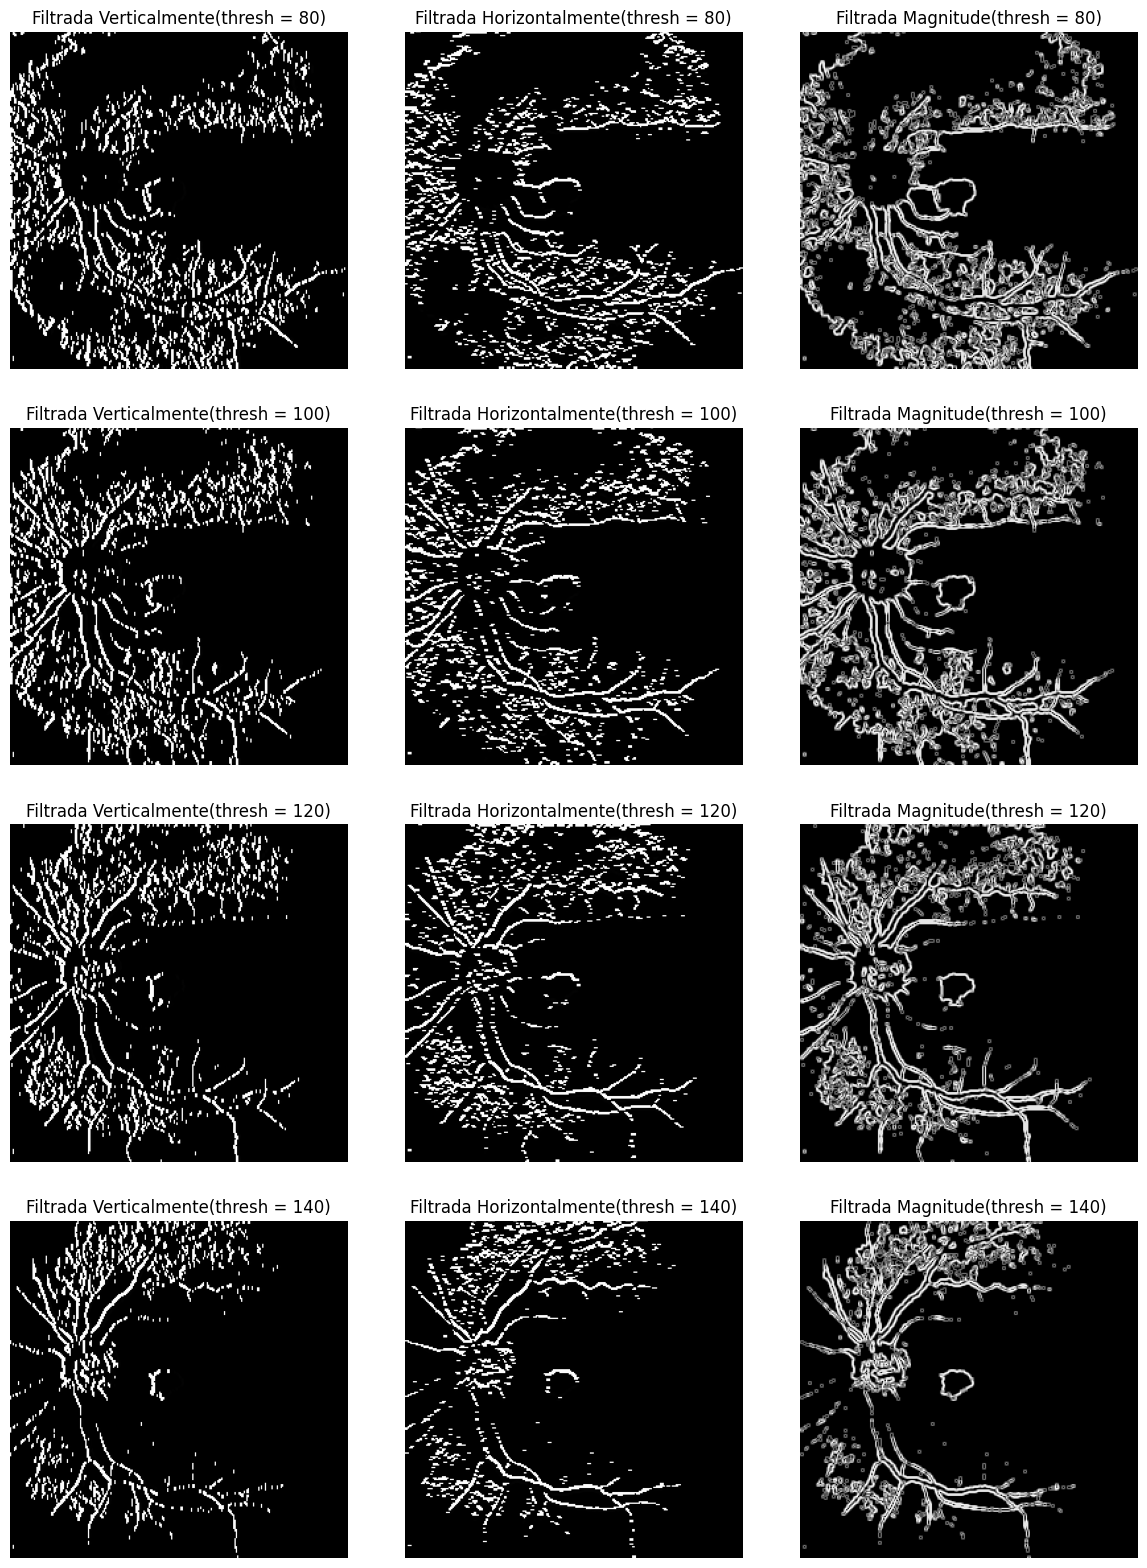

In [ ]:
def mag_sobel(fh, fv):
  fm = np.sqrt(np.pow(fh, 2) + np.pow(fv, 2))
  return fm

fig, axs = plt.subplots(4,3, figsize=(12,16))
plt.tight_layout()

cont_lista = 0
cont_plt = 1
for i in range(80, 141, 20):
  plt.subplot(4,3,cont_plt)
  plt.imshow(filtradas[cont_lista], cmap='gray')
  plt.title(f'Filtrada Verticalmente(thresh = {i})')
  plt.axis('off')
  cont_plt += 1
  cont_lista += 1

  plt.subplot(4,3,cont_plt)
  plt.imshow(filtradas[cont_lista], cmap='gray')
  plt.title(f'Filtrada Horizontalmente(thresh = {i})')
  plt.axis('off')
  cont_plt += 1
  cont_lista += 1

  plt.subplot(4,3,cont_plt)
  plt.imshow(mag_sobel(filtradas[cont_lista-1], filtradas[cont_lista-2]), cmap='gray')
  plt.title(f'Filtrada Magnitude(thresh = {i})')
  plt.axis('off')
  cont_plt += 1

**Resposta:** A partir da magnitude do filtro de Sobel, é possível identificar mais claramente as bordas da imagem, pois ele combina as bordas verticais com as horizontais, fazendo com que os detalhes fiquem mais fáceis de identificar. Neste caso, eu estou pessoalmente interessado nos vasos sanguíneos. Porém, não consigo identificar todos os detalhes com um threshold apenas. Daí a importância de usar thresholds diferentes que permitam observar diferentes detalhes dos vasos sanguíneos, o que não seria possível se usasse todo o espectro de valores de pixels.

## Parte 4 - Aprendendo filtros com CNN (opcional para EA979)

Como vimos em sala de aula, as redes neurais convolucionais (CNNs, do inglês *convolutional neural networks*) têm como base as camadas convolucionais, um banco de filtros cujos pesos são aprendidos a partir de um gabarito para predição. Para entender melhor como isso funciona, vamos praticar com redes convolucionais bem simples e visualizar como os filtros são aprendidos por elas.

Vamos utilizar um conjunto de dados composto por 60 imagens de cidades, que servirão como entradas para a nossa rede. Além das imagens originais, temos também outros dois conjuntos de imagens, obtidos após a aplicação de dois tipos de filtros diferentes nas imagens originais (Dica: ambos os filtros aplicados foram filtros vistos anteriormente neste notebook). Essas imagens filtradas servirão como nosso gabarito para que a CNN possa aprender automaticamente qual filtro foi aplicado em cada conjunto de dados, ou seja, a rede vai tentar aprender qual o filtro necessário para obter o gabarito (imagem filtrada) a partir da entrada (imagem original).

**Para mais informações sobre redes convolucionais, exemplos e boas práticas, verifique os materiais de apoio disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub. Recomendamos utilizar a biblioteca PyTorch, que será utilizada novamente em exercícios futuros.**

Abaixo, visualizamos uma imagem aleatória do conjunto e suas respectivas versões filtradas.

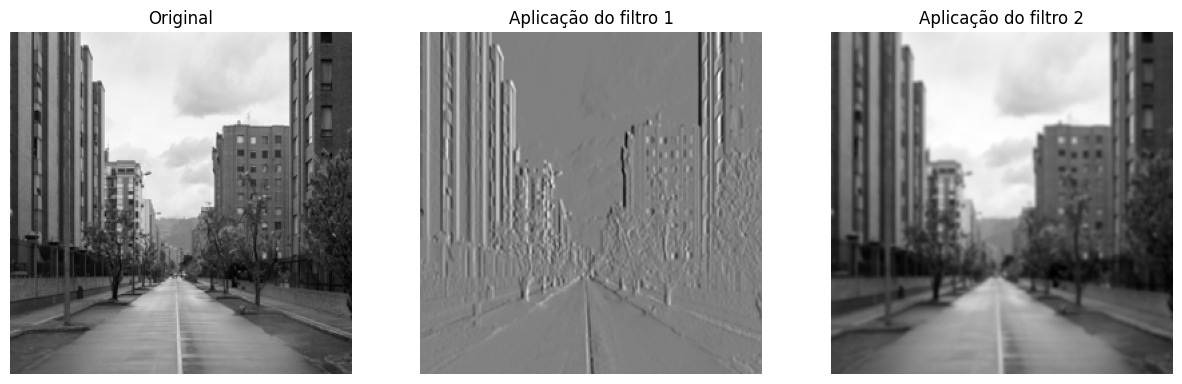

In [ ]:
path_dataset = path + 'City_images/'
selec_img = random.randint(1, 60)

img_ori = Image.open(path_dataset+'imgs_originais/'+f'{selec_img}.tif')
img_f1 = Image.open(path_dataset+'imgs_filt1/'+f'{selec_img}.tif')
img_f2 = Image.open(path_dataset+'imgs_filt2/'+f'{selec_img}.tif')

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(np.array(img_ori), cmap='gray')
plt.axis('off')
plt.title('Original')
plt.subplot(132)
plt.imshow(np.array(img_f1), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 1')
plt.subplot(133)
plt.imshow(np.array(img_f2), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 2');

Para facilitar a visualização dos filtros aprendidos pela rede, vamos utilizar o código abaixo, que gera um **gif** a partir de um conjunto de arrays. Tente entender o código a partir do exemplo dado.

In [ ]:
# Criando um conjunto de arrays para exemplificar o código
array_list = []
array_inicial = np.array([[0,0,0,0,0,0,0,0,0,0,0,0]]*6, dtype='uint8')
array_list.append(array_inicial)
for i in range(12):
    tmp = array_inicial.copy()
    tmp[2:4,:i+1] = 1
    array_list.append(tmp)

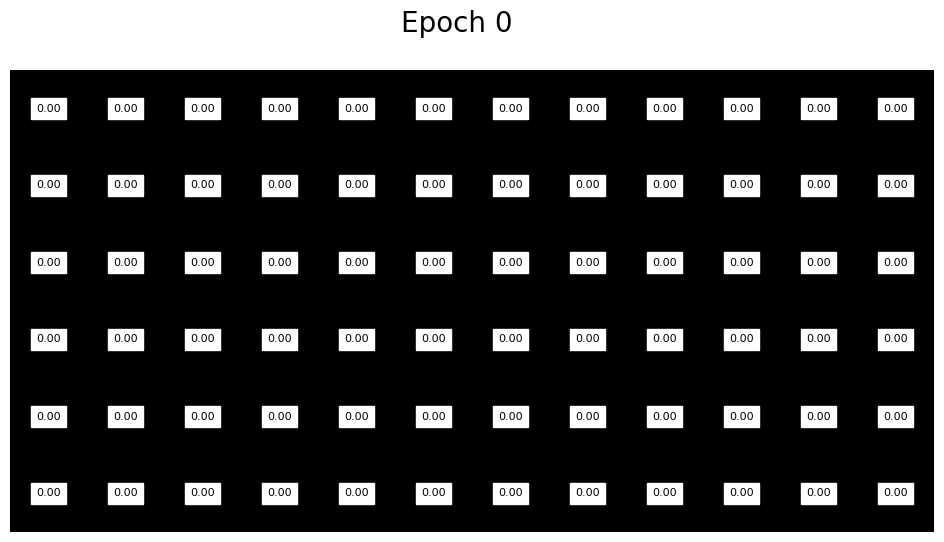

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gif generation
images = np.array(array_list)
vmin = images.min()
vmax = images.max()
fig = plt.figure(figsize=(12,6))

# Function to update the image and add text annotations
def update(frame):
    plt.clf()  # Clear the previous plot
    fig.suptitle("Epoch {}".format(frame), fontsize=20) # Define the title
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray') # Generate the image
    plt.axis('off')
    # Add text annotations
    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8, backgroundcolor='white')

# Creating the animation
anim = FuncAnimation(fig, update, frames=len(images), interval=200)
# Displaying the animation in the notebook
html = anim.to_jshtml()
HTML(html)

### Exercício 4.1

Crie uma CNN composta por apenas uma camada convolucional com kernel de tamanho 3x3, que utilize as imagens originais como entrada e tenha como "gabarito" o primeiro conjunto de imagens filtradas (**imgs_filt1**). Você precisará definir uma função de loss, um otimizador para a rede e o número de épocas para treinamento. Então, treine a rede com as imagens especificadas, acompanhando os valores de loss a cada época. Você deve armazenar em uma lista os pesos do kernel da rede a cada época do treinamento.

Após o treinamento, visualize a progressão dos pesos do kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir do **gif** obtido, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt1**?

In [ ]:
# Seu código aqui

### Exercício 4.2

Repita o processo realizado no exercício 5.1, mas dessa vez crie uma CNN composta por duas camadas convolucionais, a primeira com kernel de tamanho 1x5 e a segunda com kernel de tamanho 5x1. Você deve utilizar como "gabarito" o segundo conjunto de imagens filtradas (**imgs_filt2**). Armazene os pesos dos kernels da rede a cada época do treinamento em duas listas, uma para cada kernel.

Após o treinamento, visualize a progressão dos pesos de cada kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir dos **gifs** obtidos, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt2**?

In [ ]:
# Seu código aqui